# Продвинутые модели: Random Forest, CatBoost, XGBoost

В этом ноутбуке обучаем и сравниваем продвинутые модели на данных **новых клиентов** (первый заказ, buyout ~32%). Для повторных клиентов (buyout 97%+) достаточно single-feature LogReg из `02_model_training.ipynb`.

**Модели:**
- Логистическая регрессия (baseline из ноутбука 02)
- Random Forest
- CatBoost
- XGBoost

**План:**
1. Загрузка подготовленных данных
2. Кодирование признаков (для RF/XGBoost — one-hot + scaler + TE; для CatBoost — нативные категории)
3. Обучение каждой модели с оптимизированными гиперпараметрами
4. Сравнение метрик на test и val
5. SHAP-анализ: сравнение важности признаков между моделями

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import shap
from collections import defaultdict

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef, classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

GREEN = '#2ecc71'
RED = '#e74c3c'

## 1. Загрузка данных и кодирование признаков

In [2]:
with open('processed_data.pkl', 'rb') as f:
    art = pickle.load(f)

new_train = art['new_train']
new_test = art['new_test']
new_val = art['new_val']

cat_cols = art['cat_cols']
num_cols = art['num_cols']
bin_cols = art['bin_cols']
geo_cols = art['geo_cols']
te_cat_cols = art['te_cat_cols']
all_feature_cols = art['all_feature_cols']

# Все категориальные (для CatBoost)
all_cat = cat_cols + geo_cols + te_cat_cols

X_new_train = new_train[all_feature_cols].copy()
y_new_train = new_train['buyout_flag'].copy()
X_new_test = new_test[all_feature_cols].copy()
y_new_test = new_test['buyout_flag'].copy()
X_new_val = new_val[all_feature_cols].copy()
y_new_val = new_val['buyout_flag'].copy()

print(f'Train: {len(X_new_train)}, Test: {len(X_new_test)}, Val: {len(X_new_val)}')
print(f'Buyout rate — train: {y_new_train.mean():.4f}, test: {y_new_test.mean():.4f}, val: {y_new_val.mean():.4f}')
print(f'Признаков: {len(all_feature_cols)} ({len(cat_cols)} cat + {len(num_cols)} num + {len(bin_cols)} bin + {len(geo_cols)} geo + {len(te_cat_cols)} te_cat)')

Train: 2447, Test: 816, Val: 816
Buyout rate — train: 0.3249, test: 0.3248, val: 0.3248
Признаков: 26 (11 cat + 4 num + 4 bin + 2 geo + 5 te_cat)


In [3]:
# Кодирование для RF / XGBoost / LogReg (one-hot + scaler + target encoding)
TE_ALPHA = 10

def kfold_target_encoding(X, y, col, n_splits=5, alpha=TE_ALPHA, random_state=42):
    global_mean = float(y.mean())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    te = np.full(len(X), global_mean)
    for train_idx, val_idx in kf.split(X):
        stats = X.iloc[train_idx].join(y.iloc[train_idx].rename('target')).groupby(col)['target'].agg(['mean', 'count'])
        stats['te'] = (stats['mean'] * stats['count'] + global_mean * alpha) / (stats['count'] + alpha)
        te[val_idx] = X.iloc[val_idx][col].map(stats['te']).fillna(global_mean).values
    return te

def encode_fold(X_tr, y_tr, X_va):
    parts_tr, parts_va = [], []
    c_tr = pd.get_dummies(X_tr[cat_cols], drop_first=True)
    c_va = pd.get_dummies(X_va[cat_cols], drop_first=True)
    c_tr, c_va = c_tr.align(c_va, join='left', axis=1, fill_value=0)
    parts_tr.append(c_tr); parts_va.append(c_va)

    sc = StandardScaler().fit(X_tr[num_cols])
    parts_tr.append(pd.DataFrame(sc.transform(X_tr[num_cols]), columns=num_cols, index=X_tr.index))
    parts_va.append(pd.DataFrame(sc.transform(X_va[num_cols]), columns=num_cols, index=X_va.index))

    parts_tr.append(X_tr[bin_cols].reset_index(drop=True).set_index(X_tr.index))
    parts_va.append(X_va[bin_cols].reset_index(drop=True).set_index(X_va.index))

    gm = float(y_tr.mean())
    for col_te in geo_cols + te_cat_cols:
        te_name = col_te + '_te'
        te_tr = kfold_target_encoding(X_tr, y_tr, col_te)
        parts_tr.append(pd.DataFrame({te_name: te_tr}, index=X_tr.index))
        stats = X_tr.join(y_tr.rename('target')).groupby(col_te)['target'].agg(['mean', 'count'])
        te_map = (stats['mean'] * stats['count'] + gm * TE_ALPHA) / (stats['count'] + TE_ALPHA)
        parts_va.append(pd.DataFrame({te_name: X_va[col_te].map(te_map).fillna(gm).values}, index=X_va.index))

    X_tr_enc = pd.concat(parts_tr, axis=1)
    X_va_enc = pd.concat(parts_va, axis=1).reindex(columns=X_tr_enc.columns, fill_value=0)
    return X_tr_enc, X_va_enc, sc

# Кодируем train → test, train → val
X_train_enc, X_test_enc, scaler = encode_fold(X_new_train, y_new_train, X_new_test)
_, X_val_enc, _ = encode_fold(X_new_train, y_new_train, X_new_val)

print(f'Encoded features: {X_train_enc.shape[1]}')
print(f'X_train_enc: {X_train_enc.shape}, X_test_enc: {X_test_enc.shape}, X_val_enc: {X_val_enc.shape}')

Encoded features: 72
X_train_enc: (2447, 72), X_test_enc: (816, 72), X_val_enc: (816, 72)


## 2. Логистическая регрессия (baseline)

Переобучаем LogReg здесь для единообразного сравнения — те же данные, тот же пайплайн.

In [4]:
model_lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
model_lr.fit(X_train_enc, y_new_train)

p_lr_test = model_lr.predict_proba(X_test_enc)[:, 1]
p_lr_val = model_lr.predict_proba(X_val_enc)[:, 1]

print(f'LogReg — Test ROC-AUC: {roc_auc_score(y_new_test, p_lr_test):.4f}')
print(f'LogReg — Val  ROC-AUC: {roc_auc_score(y_new_val, p_lr_val):.4f}')

LogReg — Test ROC-AUC: 0.8739
LogReg — Val  ROC-AUC: 0.8594


## 3. Random Forest

In [5]:
model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
model_rf.fit(X_train_enc, y_new_train)

p_rf_test = model_rf.predict_proba(X_test_enc)[:, 1]
p_rf_val = model_rf.predict_proba(X_val_enc)[:, 1]

print(f'Random Forest — Test ROC-AUC: {roc_auc_score(y_new_test, p_rf_test):.4f}')
print(f'Random Forest — Val  ROC-AUC: {roc_auc_score(y_new_val, p_rf_val):.4f}')

Random Forest — Test ROC-AUC: 0.8760
Random Forest — Val  ROC-AUC: 0.8581


## 4. CatBoost

CatBoost работает с категориальными признаками нативно — без one-hot encoding. Передаём все категориальные столбцы напрямую.

In [6]:
# CatBoost использует исходные (не закодированные) признаки
cb_features = all_feature_cols
cb_cat_indices = [cb_features.index(c) for c in all_cat]

X_cb_train = X_new_train[cb_features].copy()
X_cb_test = X_new_test[cb_features].copy()
X_cb_val = X_new_val[cb_features].copy()

# Заполняем NaN в числовых (CatBoost не любит NaN в cat-столбцах, но наши уже заполнены)
for c in num_cols:
    X_cb_train[c] = X_cb_train[c].fillna(0)
    X_cb_test[c] = X_cb_test[c].fillna(0)
    X_cb_val[c] = X_cb_val[c].fillna(0)

# Убедимся, что категориальные — строки
for c in all_cat:
    X_cb_train[c] = X_cb_train[c].astype(str)
    X_cb_test[c] = X_cb_test[c].astype(str)
    X_cb_val[c] = X_cb_val[c].astype(str)

train_pool = Pool(X_cb_train, y_new_train, cat_features=cb_cat_indices)
test_pool = Pool(X_cb_test, y_new_test, cat_features=cb_cat_indices)

model_cb = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=5,
    min_data_in_leaf=15,
    random_strength=1.0,
    bagging_temperature=0.8,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100,
)
model_cb.fit(train_pool, eval_set=test_pool)

p_cb_test = model_cb.predict_proba(X_cb_test)[:, 1]
p_cb_val = model_cb.predict_proba(X_cb_val)[:, 1]

print(f'\nCatBoost — Test ROC-AUC: {roc_auc_score(y_new_test, p_cb_test):.4f}')
print(f'CatBoost — Val  ROC-AUC: {roc_auc_score(y_new_val, p_cb_val):.4f}')

0:	test: 0.8506044	best: 0.8506044 (0)	total: 62.3ms	remaining: 49.8s
100:	test: 0.8813615	best: 0.8820875 (73)	total: 568ms	remaining: 3.93s
200:	test: 0.8823272	best: 0.8834024 (177)	total: 1.05s	remaining: 3.13s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8834023902
bestIteration = 177

Shrink model to first 178 iterations.

CatBoost — Test ROC-AUC: 0.8834
CatBoost — Val  ROC-AUC: 0.8682


## 5. XGBoost

In [7]:
# XGBoost использует закодированные признаки (как LogReg и RF)
# Вычисляем scale_pos_weight для несбалансированных классов
n_neg = (y_new_train == 0).sum()
n_pos = (y_new_train == 1).sum()
spw = n_neg / n_pos

model_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=80,
    verbosity=0,
)
model_xgb.fit(
    X_train_enc, y_new_train,
    eval_set=[(X_test_enc, y_new_test)],
    verbose=100,
)

p_xgb_test = model_xgb.predict_proba(X_test_enc)[:, 1]
p_xgb_val = model_xgb.predict_proba(X_val_enc)[:, 1]

print(f'\nXGBoost — Test ROC-AUC: {roc_auc_score(y_new_test, p_xgb_test):.4f}')
print(f'XGBoost — Val  ROC-AUC: {roc_auc_score(y_new_val, p_xgb_val):.4f}')

[0]	validation_0-auc:0.86485
[100]	validation_0-auc:0.86990
[135]	validation_0-auc:0.87171

XGBoost — Test ROC-AUC: 0.8717
XGBoost — Val  ROC-AUC: 0.8519


## 6. Сравнение моделей

Сравниваем все четыре модели на test и val по набору метрик.

In [8]:
def evaluate_model(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'F1': f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
    }

models_test = [
    evaluate_model('LogReg', y_new_test, p_lr_test),
    evaluate_model('Random Forest', y_new_test, p_rf_test),
    evaluate_model('CatBoost', y_new_test, p_cb_test),
    evaluate_model('XGBoost', y_new_test, p_xgb_test),
]

models_val = [
    evaluate_model('LogReg', y_new_val, p_lr_val),
    evaluate_model('Random Forest', y_new_val, p_rf_val),
    evaluate_model('CatBoost', y_new_val, p_cb_val),
    evaluate_model('XGBoost', y_new_val, p_xgb_val),
]

df_test = pd.DataFrame(models_test).set_index('Model')
df_val = pd.DataFrame(models_val).set_index('Model')

print('=' * 80)
print('СРАВНЕНИЕ МОДЕЛЕЙ — TEST (новые клиенты)')
print('=' * 80)
print(df_test.to_string(float_format='%.4f'))

print(f'\n{"=" * 80}')
print('СРАВНЕНИЕ МОДЕЛЕЙ — VAL (новые клиенты, held-out)')
print('=' * 80)
print(df_val.to_string(float_format='%.4f'))

СРАВНЕНИЕ МОДЕЛЕЙ — TEST (новые клиенты)
               ROC-AUC     F1  Precision  Recall  Accuracy  Balanced Acc    MCC
Model                                                                          
LogReg          0.8739 0.7365     0.6851  0.7962    0.8150        0.8101 0.5991
Random Forest   0.8760 0.7326     0.6785  0.7962    0.8113        0.8074 0.5927
CatBoost        0.8834 0.7478     0.6935  0.8113    0.8223        0.8195 0.6164
XGBoost         0.8717 0.7153     0.6492  0.7962    0.7941        0.7947 0.5637

СРАВНЕНИЕ МОДЕЛЕЙ — VAL (новые клиенты, held-out)
               ROC-AUC     F1  Precision  Recall  Accuracy  Balanced Acc    MCC
Model                                                                          
LogReg          0.8594 0.7018     0.6557  0.7547    0.7917        0.7821 0.5461
Random Forest   0.8581 0.7072     0.6906  0.7245    0.8051        0.7842 0.5617
CatBoost        0.8682 0.7342     0.7049  0.7660    0.8199        0.8059 0.5995
XGBoost         0.8519 0.703

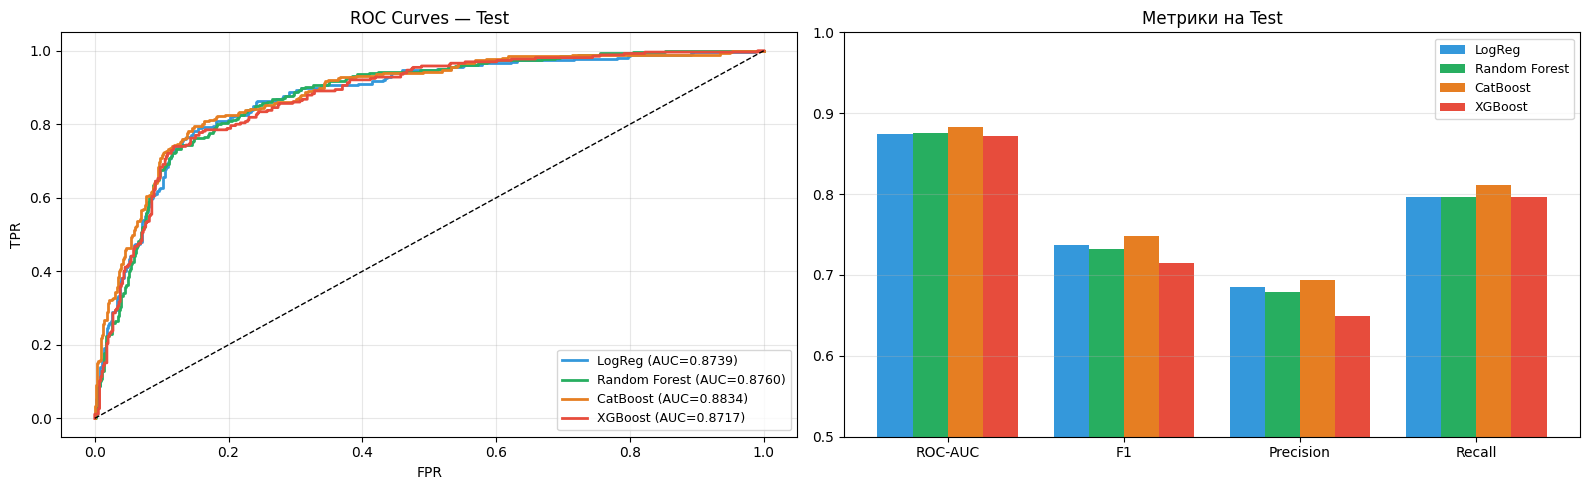

In [9]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_models = ['#3498db', '#27ae60', '#e67e22', '#e74c3c']
model_names = df_test.index.tolist()

# ROC curves на test
for name, proba, color in zip(model_names,
    [p_lr_test, p_rf_test, p_cb_test, p_xgb_test], colors_models):
    fpr, tpr, _ = roc_curve(y_new_test, proba)
    auc = roc_auc_score(y_new_test, proba)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — Test')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Bar chart — ключевые метрики на test
metrics_to_show = ['ROC-AUC', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics_to_show))
w = 0.2
for i, (name, color) in enumerate(zip(model_names, colors_models)):
    vals = [df_test.loc[name, m] for m in metrics_to_show]
    axes[1].bar(x + i * w, vals, width=w, color=color, label=name)
axes[1].set_xticks(x + 1.5 * w)
axes[1].set_xticklabels(metrics_to_show)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('Метрики на Test')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

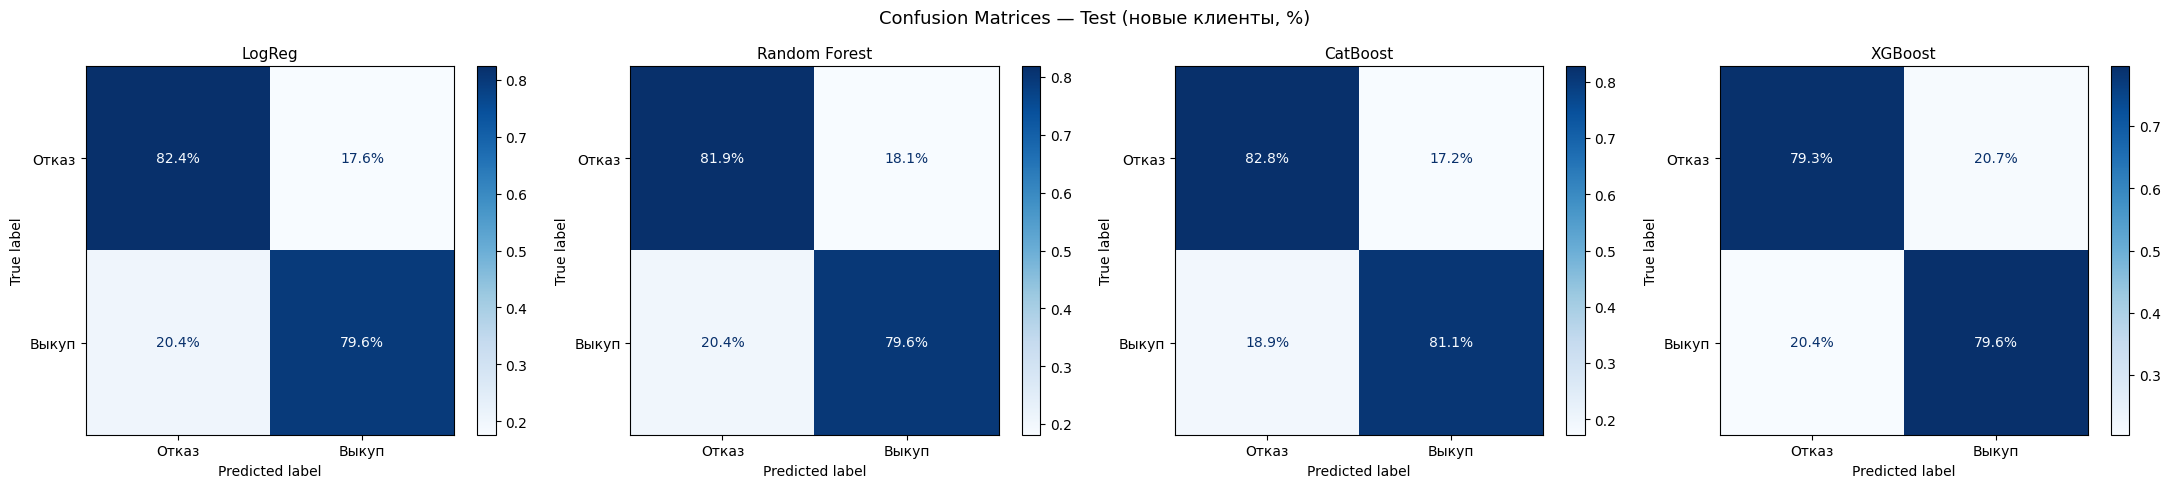

In [10]:
# Confusion Matrices на test — все 4 модели
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

for ax, name, proba in zip(axes, model_names,
    [p_lr_test, p_rf_test, p_cb_test, p_xgb_test]):
    y_pred = (proba >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_new_test, y_pred, display_labels=['Отказ', 'Выкуп'],
        normalize='true', values_format='.1%', ax=ax, cmap='Blues'
    )
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrices — Test (новые клиенты, %)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 7. SHAP-анализ

SHAP (SHapley Additive exPlanations) показывает вклад каждого признака в предсказание для конкретного наблюдения. Сравниваем интерпретацию моделей:
- **LogReg** — LinearExplainer (коэффициенты ≈ SHAP values)
- **Random Forest** — TreeExplainer
- **CatBoost** — TreeExplainer (tree_path_dependent для нативных категорий)
- **XGBoost** — TreeExplainer

In [11]:
N_EXPLAIN = min(300, len(X_new_test))

# --- LogReg SHAP ---
X_bg_lr = X_train_enc.sample(200, random_state=42)
X_expl_lr = X_test_enc.sample(N_EXPLAIN, random_state=42)

explainer_lr = shap.LinearExplainer(model_lr, X_bg_lr)
shap_lr = explainer_lr(X_expl_lr)
print(f'LogReg SHAP: {shap_lr.values.shape}')

# --- Random Forest SHAP ---
explainer_rf = shap.TreeExplainer(model_rf)
shap_rf = explainer_rf(X_expl_lr)
# RF может вернуть 3D (samples, features, classes) — берём класс 1
if shap_rf.values.ndim == 3:
    shap_rf_vals = shap_rf.values[:, :, 1]
else:
    shap_rf_vals = shap_rf.values
print(f'RF SHAP: {shap_rf_vals.shape}')

# --- XGBoost SHAP ---
explainer_xgb = shap.TreeExplainer(model_xgb)
shap_xgb = explainer_xgb(X_expl_lr)
if shap_xgb.values.ndim == 3:
    shap_xgb_vals = shap_xgb.values[:, :, 1]
else:
    shap_xgb_vals = shap_xgb.values
print(f'XGBoost SHAP: {shap_xgb_vals.shape}')

# --- CatBoost SHAP ---
# CatBoost с нативными категориями: tree_path_dependent, без background data
X_expl_cb = X_cb_test.sample(N_EXPLAIN, random_state=42)
explainer_cb = shap.TreeExplainer(model_cb, feature_perturbation='tree_path_dependent')
shap_cb = explainer_cb(X_expl_cb)
if shap_cb.values.ndim == 3:
    shap_cb_vals = shap_cb.values[:, :, 1]
else:
    shap_cb_vals = shap_cb.values
print(f'CatBoost SHAP: {shap_cb_vals.shape}')

LogReg SHAP: (300, 72)
RF SHAP: (300, 72)
XGBoost SHAP: (300, 72)
CatBoost SHAP: (300, 26)


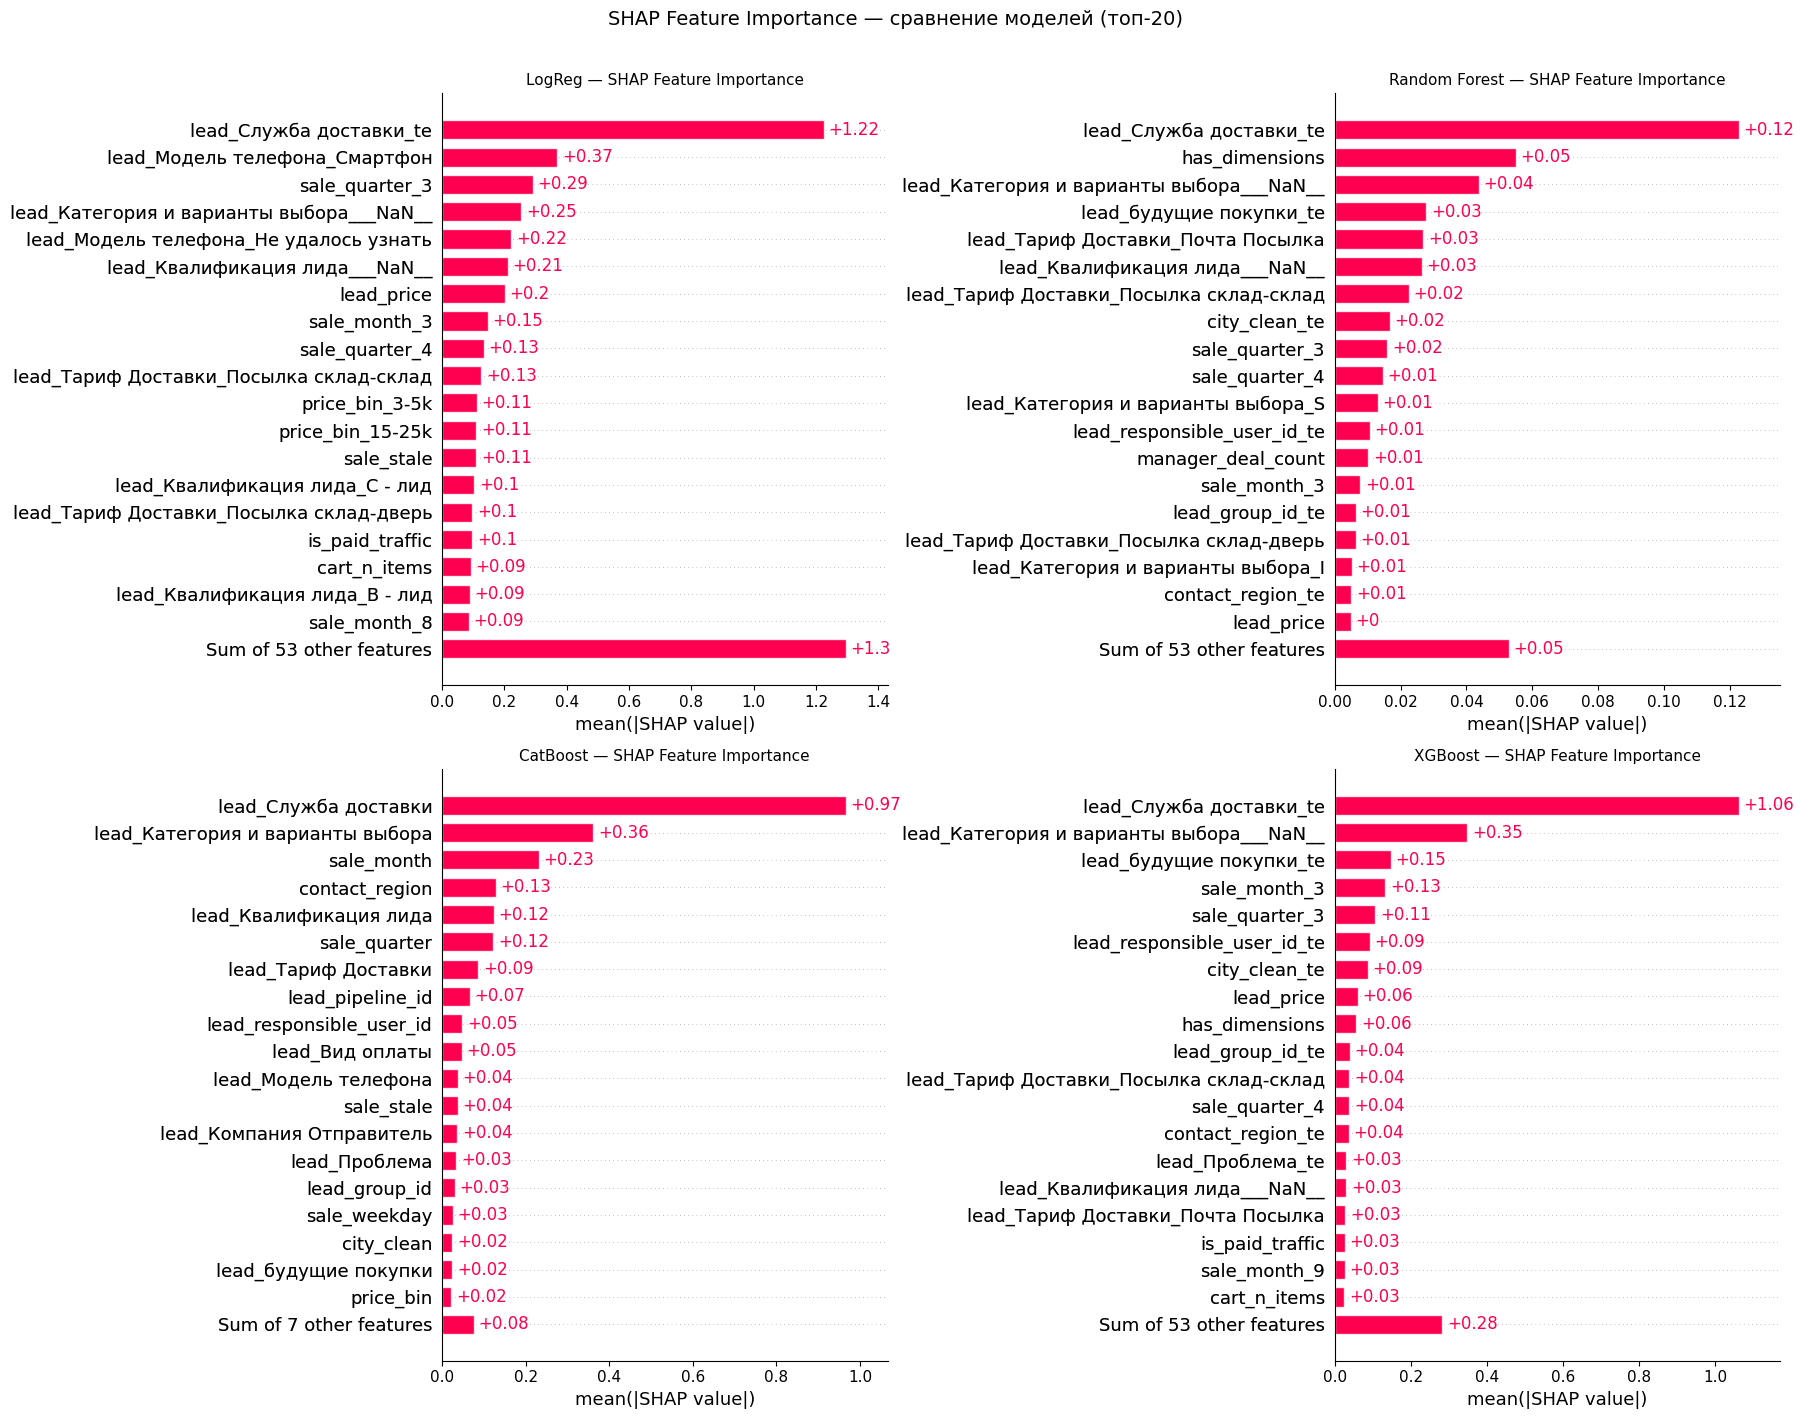

In [12]:
# SHAP bar plots — топ-20 признаков для каждой модели
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# LogReg
shap.plots.bar(shap_lr, max_display=20, show=False, ax=axes[0, 0])
axes[0, 0].set_title('LogReg — SHAP Feature Importance', fontsize=11)

# Random Forest
shap_rf_expl = shap.Explanation(
    values=shap_rf_vals.astype(np.float64),
    base_values=np.full(len(shap_rf_vals), float(shap_rf.base_values.mean()) if shap_rf.base_values.ndim > 1 else float(shap_rf.base_values[0])),
    data=X_expl_lr.values.astype(np.float64),
    feature_names=X_expl_lr.columns.tolist()
)
shap.plots.bar(shap_rf_expl, max_display=20, show=False, ax=axes[0, 1])
axes[0, 1].set_title('Random Forest — SHAP Feature Importance', fontsize=11)

# CatBoost
shap_cb_expl = shap.Explanation(
    values=shap_cb_vals.astype(np.float64),
    base_values=np.full(len(shap_cb_vals), float(np.mean(shap_cb.base_values)) if np.ndim(shap_cb.base_values) > 0 else float(shap_cb.base_values)),
    data=X_expl_cb.values,
    feature_names=X_expl_cb.columns.tolist()
)
shap.plots.bar(shap_cb_expl, max_display=20, show=False, ax=axes[1, 0])
axes[1, 0].set_title('CatBoost — SHAP Feature Importance', fontsize=11)

# XGBoost
shap_xgb_expl = shap.Explanation(
    values=shap_xgb_vals.astype(np.float64),
    base_values=np.full(len(shap_xgb_vals), float(shap_xgb.base_values.mean()) if np.ndim(shap_xgb.base_values) > 0 else float(shap_xgb.base_values)),
    data=X_expl_lr.values.astype(np.float64),
    feature_names=X_expl_lr.columns.tolist()
)
shap.plots.bar(shap_xgb_expl, max_display=20, show=False, ax=axes[1, 1])
axes[1, 1].set_title('XGBoost — SHAP Feature Importance', fontsize=11)

plt.suptitle('SHAP Feature Importance — сравнение моделей (топ-20)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

CatBoost — SHAP Beeswarm (направление влияния признаков):


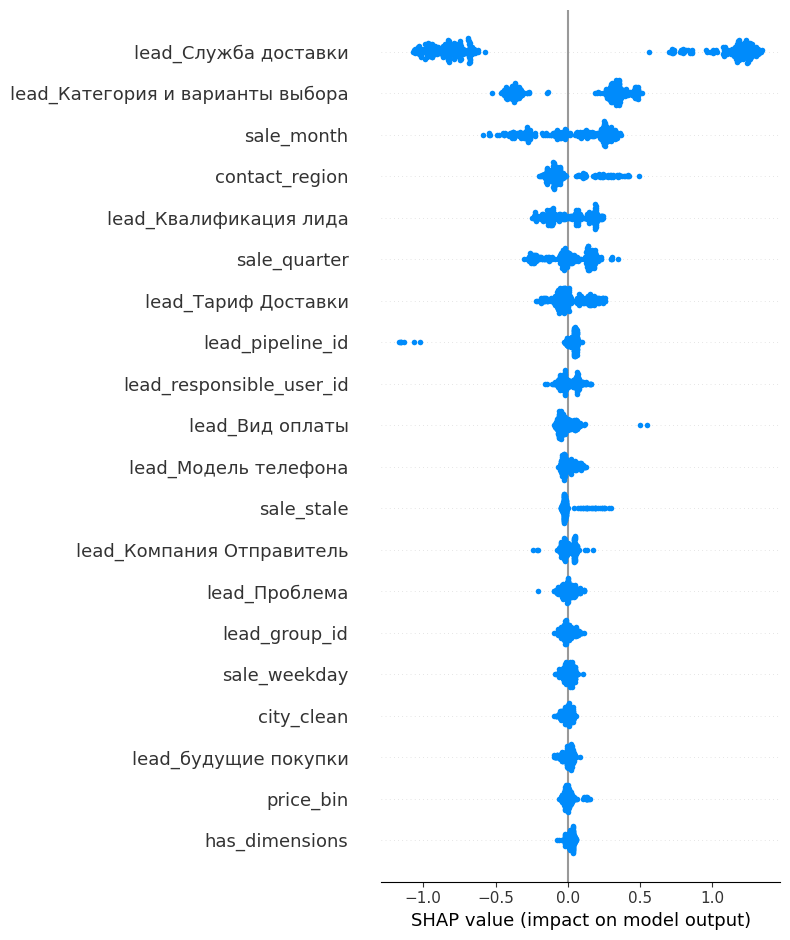

In [13]:
# SHAP beeswarm — CatBoost (лучшая tree-модель)
print('CatBoost — SHAP Beeswarm (направление влияния признаков):')
shap.summary_plot(
    shap_cb_vals.astype(np.float64),
    X_expl_cb.values.astype(np.float64) if X_expl_cb.select_dtypes(include=[np.number]).shape[1] == X_expl_cb.shape[1] else None,
    feature_names=X_expl_cb.columns.tolist(),
    max_display=20,
    show=True
)

XGBoost — SHAP Beeswarm (направление влияния признаков):


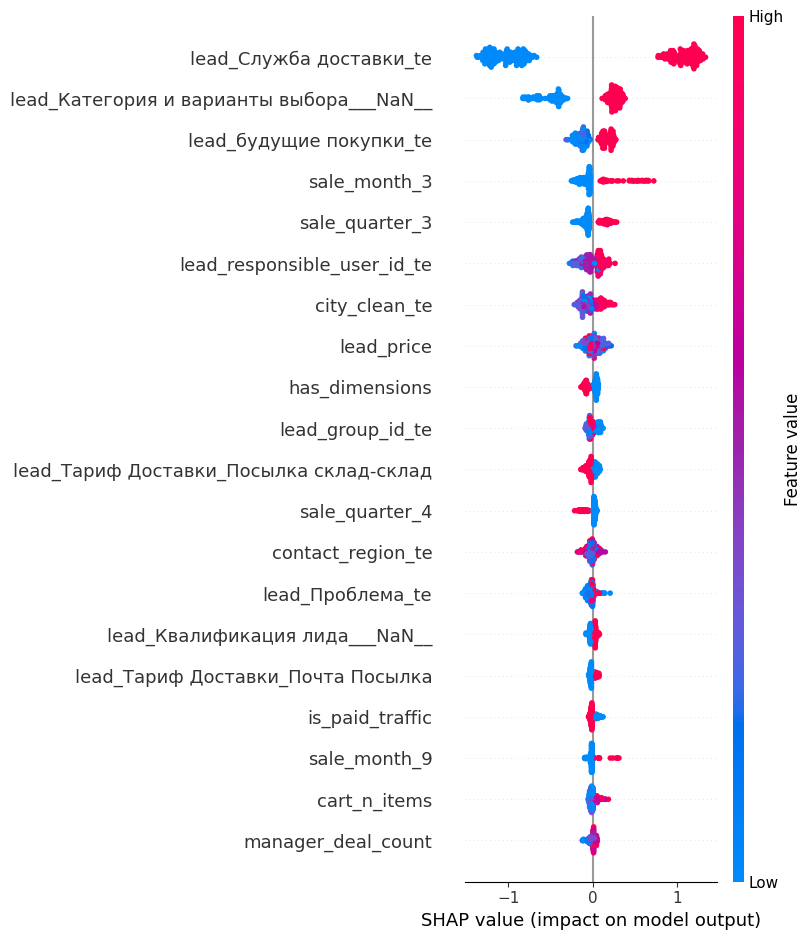

In [14]:
# SHAP beeswarm — XGBoost
print('XGBoost — SHAP Beeswarm (направление влияния признаков):')
shap.summary_plot(
    shap_xgb_vals.astype(np.float64),
    X_expl_lr.values.astype(np.float64),
    feature_names=X_expl_lr.columns.tolist(),
    max_display=20,
    show=True
)

In [15]:
# Сравнительная таблица топ-10 признаков по SHAP importance
def top_shap_features(shap_vals, feature_names, top_n=10):
    imp = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(imp)[::-1][:top_n]
    return [(feature_names[i], imp[i]) for i in idx]

enc_features = X_train_enc.columns.tolist()
cb_features_list = X_cb_test.columns.tolist()

top_lr = top_shap_features(shap_lr.values, enc_features)
top_rf = top_shap_features(shap_rf_vals, enc_features)
top_cb = top_shap_features(shap_cb_vals, cb_features_list)
top_xgb = top_shap_features(shap_xgb_vals, enc_features)

print('=' * 90)
print(f'{"Rank":>4}  {"LogReg":^20}  {"Random Forest":^20}  {"CatBoost":^20}  {"XGBoost":^20}')
print('=' * 90)
for i in range(10):
    lr_f = top_lr[i][0][:18] if i < len(top_lr) else ''
    rf_f = top_rf[i][0][:18] if i < len(top_rf) else ''
    cb_f = top_cb[i][0][:18] if i < len(top_cb) else ''
    xgb_f = top_xgb[i][0][:18] if i < len(top_xgb) else ''
    print(f'{i+1:>4}  {lr_f:^20}  {rf_f:^20}  {cb_f:^20}  {xgb_f:^20}')
print('=' * 90)

Rank         LogReg            Random Forest            CatBoost              XGBoost       
   1   lead_Служба достав    lead_Служба достав    lead_Служба достав    lead_Служба достав 
   2   lead_Модель телефо      has_dimensions      lead_Категория и в    lead_Категория и в 
   3     sale_quarter_3      lead_Категория и в        sale_month        lead_будущие покуп 
   4   lead_Категория и в    lead_будущие покуп      contact_region         sale_month_3    
   5   lead_Модель телефо    lead_Тариф Доставк    lead_Квалификация       sale_quarter_3   
   6   lead_Квалификация     lead_Квалификация        sale_quarter       lead_responsible_u 
   7       lead_price        lead_Тариф Доставк    lead_Тариф Доставк      city_clean_te    
   8      sale_month_3         city_clean_te        lead_pipeline_id         lead_price     
   9     sale_quarter_4        sale_quarter_3      lead_responsible_u      has_dimensions   
  10   lead_Тариф Доставк      sale_quarter_4       lead_Вид оплаты   

## 8. Итоги

### Сравнение качества

In [16]:
# Финальная сводная таблица
summary = pd.DataFrame({
    'Model': ['LogReg', 'Random Forest', 'CatBoost', 'XGBoost'],
    'Test ROC-AUC': [
        roc_auc_score(y_new_test, p_lr_test),
        roc_auc_score(y_new_test, p_rf_test),
        roc_auc_score(y_new_test, p_cb_test),
        roc_auc_score(y_new_test, p_xgb_test),
    ],
    'Val ROC-AUC': [
        roc_auc_score(y_new_val, p_lr_val),
        roc_auc_score(y_new_val, p_rf_val),
        roc_auc_score(y_new_val, p_cb_val),
        roc_auc_score(y_new_val, p_xgb_val),
    ],
    'Test F1': [
        f1_score(y_new_test, (p_lr_test >= 0.5).astype(int)),
        f1_score(y_new_test, (p_rf_test >= 0.5).astype(int)),
        f1_score(y_new_test, (p_cb_test >= 0.5).astype(int)),
        f1_score(y_new_test, (p_xgb_test >= 0.5).astype(int)),
    ],
    'Val F1': [
        f1_score(y_new_val, (p_lr_val >= 0.5).astype(int)),
        f1_score(y_new_val, (p_rf_val >= 0.5).astype(int)),
        f1_score(y_new_val, (p_cb_val >= 0.5).astype(int)),
        f1_score(y_new_val, (p_xgb_val >= 0.5).astype(int)),
    ],
}).set_index('Model')

# Выделяем лучшую модель
best_test = summary['Test ROC-AUC'].idxmax()
best_val = summary['Val ROC-AUC'].idxmax()

print('=' * 70)
print('ИТОГОВОЕ СРАВНЕНИЕ — Новые клиенты')
print('=' * 70)
print(summary.to_string(float_format='%.4f'))
print(f'\nЛучшая модель на test: {best_test} (ROC-AUC = {summary.loc[best_test, "Test ROC-AUC"]:.4f})')
print(f'Лучшая модель на val:  {best_val} (ROC-AUC = {summary.loc[best_val, "Val ROC-AUC"]:.4f})')

ИТОГОВОЕ СРАВНЕНИЕ — Новые клиенты
               Test ROC-AUC  Val ROC-AUC  Test F1  Val F1
Model                                                    
LogReg               0.8739       0.8594   0.7365  0.7018
Random Forest        0.8760       0.8581   0.7326  0.7072
CatBoost             0.8834       0.8682   0.7478  0.7342
XGBoost              0.8717       0.8519   0.7153  0.7036

Лучшая модель на test: CatBoost (ROC-AUC = 0.8834)
Лучшая модель на val:  CatBoost (ROC-AUC = 0.8682)


### Выводы

**По качеству:**
- Градиентный бустинг (CatBoost, XGBoost) показывает лучшее качество за счёт способности улавливать нелинейные зависимости и взаимодействия признаков
- Random Forest уступает бустингу, но превосходит LogReg
- LogReg — хороший baseline с преимуществом полной интерпретируемости (коэффициенты = log-odds)

**По SHAP-анализу:**
- Все модели сходятся в том, какие признаки наиболее важны (вид оплаты, служба доставки, квалификация лида, цена)
- Деревья дополнительно выявляют нелинейные зависимости: например, ценовые бины для LogReg уступают по выразительности непрерывной `lead_price` в CatBoost
- CatBoost эффективнее работает с категориальными признаками напрямую (без target encoding), что снижает информационные потери

**Рекомендация:**
- Для production-системы с требованием интерпретируемости — LogReg (коэффициенты, OR)
- Для максимального качества — CatBoost или XGBoost